In [1]:
import sys
sys.path.append('../src')

from utils import P300Getter
from graph import get_delaunay_graph, get_pos_init_graph, plot_graph, get_neighbors_graph

In [2]:
import mne
import pandas as pd
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
from tqdm import tqdm

import torch
from torch import nn, optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F

from scipy.spatial import Delaunay
import networkx as nx
import scipy.sparse as sp
import time
from sklearn.neighbors import NearestNeighbors

from mne import Epochs, pick_types, events_from_annotations
from mne.channels import make_standard_montage, DigMontage
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
from mne.decoding import Scaler

from torch_geometric.data import Data, InMemoryDataset

import wandb
import pickle

In [3]:
import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import os

import pathlib

In [4]:
from IPython.display import clear_output

In [5]:
DATA_PATH = pathlib.Path(r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\matrix_dataset')

train_A_raw = scipy.io.loadmat(DATA_PATH / 'Subject_A_Train.mat')
test_A_raw = scipy.io.loadmat(DATA_PATH / 'Subject_A_Test.mat')

eloc = mne.channels.read_custom_montage(DATA_PATH / 'eloc64.txt')
info = mne.create_info(ch_names=eloc.ch_names, ch_types=['eeg'] * 64, sfreq=240)

train_A_chars = list(train_A_raw['TargetChar'][0])
test_A_chars = list('WQXPLZCOMRKO97YFZDEZ1DPI9NNVGRQDJCUVRMEUOOOJD2UFYPOO6J7LDGYEGOA5VHNEHBTXOO1TDOILUEE5BFAEEXAW_K4R3MRU')

A_train_ds = P300Getter(train_A_raw, eloc, sample_size=72)
A_test_ds = P300Getter(test_A_raw, eloc, sample_size=72, target_chars=test_A_chars)

A_train_ds.get_cnn_p300_dataset(filter=True)
A_test_ds.get_cnn_p300_dataset(filter=True)

A_train_ds.upsample(4)
#A_test_ds.upsample(2)

X_train_A, y_train_A = A_train_ds.get_data()
X_test_A, y_test_A = A_test_ds.get_data()

clear_output()
print("Success")

Success


In [6]:
def plot_graph(G):
    labels = dict()
    pos = []

    for i, node in enumerate(G.nodes):
        labels[i] = G.nodes[i]['label']
        pos.append(G.nodes[i]['pos'])

    pos = np.array(pos)

    nx.draw(G, labels=labels, font_weight='bold', pos=pos[:,:2])
    plt.show()
    nx.draw(G, labels=labels, font_weight='bold', pos=pos[:,1:])
    plt.show()
    nx.draw(G, labels=labels, font_weight='bold', pos=pos[:,[0, 2]])
    plt.show()


def get_delaunay_graph(eloc, picture=False):
    positions = eloc.get_positions()['ch_pos']
    points = np.stack(list(positions.values()))
    ch_names = np.stack(list(positions.keys()))

    tri = Delaunay(points)

    G = nx.Graph()
    for ind, (pos, label) in enumerate(zip(points, ch_names)):
        G.add_node(ind, pos=pos, label=label)

    for path in tri.simplices[:, 1:]:
        nx.add_cycle(G, path)

    #for node in [23, 26, 34, 35, 28, 36]:
    #    G.add_edge(27, node)

    #G.remove_edge(63, 42)
    #G.remove_edge(63, 43)
    #G.remove_edge(42, 43)

    if picture:
        plot_graph(G)

    return nx.adjacency_matrix(G).todense()


def get_neighbors_graph(eloc, n_neighbors=9, picture=False):
    positions = eloc.get_positions()['ch_pos']
    points = np.stack(list(positions.values()))
    ch_names = np.stack(list(positions.keys()))

    neigh = NearestNeighbors(n_neighbors=n_neighbors)
    neigh.fit(points)

    neighbors_list = neigh.kneighbors(points, return_distance=True)[1]

    G = nx.Graph()
    for ind, (pos, label) in enumerate(zip(points, ch_names)):
        G.add_node(ind, pos=pos, label=label)

    for path in neighbors_list:
        for neighbor in path[1:]:
            G.add_edge(path[0], neighbor)

    if picture:
        plot_graph(G)

    return nx.adjacency_matrix(G).todense()

def get_pos_init_graph(eloc, delta=0.0025):
    positions = eloc.get_positions()['ch_pos']
    points = np.stack(list(positions.values()))

    matrix = np.zeros((len(points), len(points)))

    for i, point_i in enumerate(points):
        for j, point_j in enumerate(points):
            matrix[i,j] = np.clip(delta / np.power(point_i - point_j + 1e-5, 2).sum(), 0.1, 1)

    return matrix

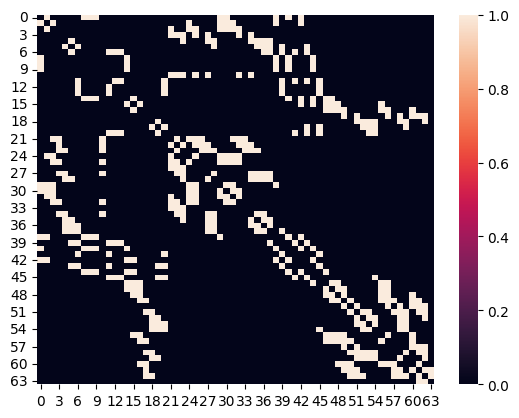

In [7]:
neighbors_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\neighbors_init.bin'

neighbors_graph = get_neighbors_graph(eloc, n_neighbors=9, picture=False)
neighbors_graph = torch.Tensor(neighbors_graph)

sns.heatmap(neighbors_graph)

with open(neighbors_path, 'wb') as f:
    pickle.dump(
        obj=neighbors_graph,
        file=f
    )

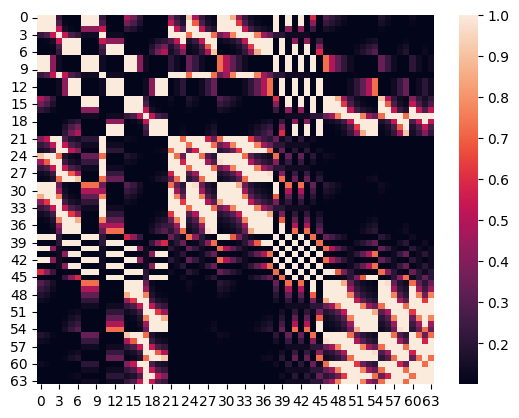

In [8]:
pos_init_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\pos_init.bin'

pos_init_graph = get_pos_init_graph(eloc)
pos_init_graph = torch.Tensor(pos_init_graph)

sns.heatmap(pos_init_graph)

with open(pos_init_path, 'wb') as f:
    pickle.dump(
        obj=pos_init_graph,
        file=f
    )

In [9]:
delaunay_path = r'C:\Users\Vladimir\PycharmProjects\EEGPatternRecognition\delaunay_init.bin'

delaunay_graph = get_delaunay_graph(eloc, picture=False)
delaunay_graph = torch.Tensor(delaunay_graph)

sns.heatmap(delaunay_graph)

# with open(delaunay_path, 'wb') as f:
#     pickle.dump(
#         obj=delaunay_graph,
#         file=f
#     )

QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull d Qz Qbb Q12 Qt Qc
Options selected for Qhull 2019.1.r 2019/06/21:
  run-id 802709502  delaunay  Qz-infinity-point  Qbbound-last  Q12-allow-wide
  Qtriangulate  Qcoplanar-keep  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width 0.19  Error-roundoff 1.9e-16  _one-merge 1.7e-15
  Visible-distance 1.1e-15  U-max-coplanar 1.1e-15  Width-outside 2.3e-15
  _wide-facet 6.9e-15  _maxoutside 2.3e-15

precision problems (corrected unless 'Q0' or an error)
      1 degenerate hyperplanes recomputed with gaussian elimination
      1 nearly singular or axis-parallel hyperplanes
      1 zero divisors during back substitute
     66 zero divisors during gaussian elimination

The input to qhull appears to be less than 4 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p3(v5):     0     0 0.095